In [21]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("airquality.csv")
df.head(6)


,rownames,Ozone,Solar.R,Wind,Temp,Month,Day
0,1,41.0,190.0,7.4,67,5,1
1,2,36.0,118.0,8.0,72,5,2
2,3,12.0,149.0,12.6,74,5,3
3,4,18.0,313.0,11.5,62,5,4
4,5,NaN,NaN,14.3,56,5,5
5,6,28.0,NaN,14.9,66,5,6


In [22]:
print("Shape:", df.shape)
print("Data Types:")
print(df.dtypes)
print("Dataset Information:")
df.info()

Shape: (153, 7)
Data Types:
rownames      int64
Ozone       float64
Solar.R     float64
Wind        float64
Temp          int64
Month         int64
Day           int64
dtype: object
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  153 non-null    int64  
 1   Ozone     116 non-null    float64
 2   Solar.R   146 non-null    float64
 3   Wind      153 non-null    float64
 4   Temp      153 non-null    int64  
 5   Month     153 non-null    int64  
 6   Day       153 non-null    int64  
dtypes: float64(3), int64(4)
memory usage: 8.5 KB


In [23]:
cols = ['Ozone', 'Solar.R', 'Wind', 'Temp']
print("Mean:")
print(df[cols].mean())
print("Median:")
print(df[cols].median())
print("Mode using pandas:")
print(df[cols].mode())

Mean:
Ozone       42.129310
Solar.R    185.931507
Wind         9.957516
Temp        77.882353
dtype: float64
Median:
Ozone       31.5
Solar.R    205.0
Wind         9.7
Temp        79.0
dtype: float64
Mode using pandas:
   Ozone  Solar.R  Wind  Temp
0   23.0    238.0  11.5  81.0
1    NaN    259.0   NaN   NaN


In [24]:
def custom_mode(series):
    counts = series.value_counts()
    max_count = counts.max()
    return counts[counts == max_count].index.tolist()
print("Custom Mode:")
for col in cols:
    print(col, ":", custom_mode(df[col].dropna()))

Custom Mode:
Ozone : [23.0]
Solar.R : [259.0, 238.0]
Wind : [11.5]
Temp : [81]


In [25]:
print("Pandas Mode:")
print(df[cols].mode())

print("Custom Mode:")
for col in cols:
    print(col, ":", custom_mode(df[col].dropna()))

Pandas Mode:
   Ozone  Solar.R  Wind  Temp
0   23.0    238.0  11.5  81.0
1    NaN    259.0   NaN   NaN
Custom Mode:
Ozone : [23.0]
Solar.R : [259.0, 238.0]
Wind : [11.5]
Temp : [81]


In [26]:
print("Standard Deviation:")
print(df[cols].std())

print("Variance:")
print(df[cols].var())

Standard Deviation:
Ozone      32.987885
Solar.R    90.058422
Wind        3.523001
Temp        9.465270
dtype: float64
Variance:
Ozone      1088.200525
Solar.R    8110.519414
Wind         12.411539
Temp         89.591331
dtype: float64


In [27]:
print("Minimum:")
print(df[cols].min())

print("Maximum:")
print(df[cols].max())

print("IQR:")
iqr = df[cols].quantile(0.75) - df[cols].quantile(0.25)
print(iqr)

Minimum:
Ozone       1.0
Solar.R     7.0
Wind        1.7
Temp       56.0
dtype: float64
Maximum:
Ozone      168.0
Solar.R    334.0
Wind        20.7
Temp        97.0
dtype: float64
IQR:
Ozone       45.25
Solar.R    143.00
Wind         4.10
Temp        13.00
dtype: float64


In [28]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
rownames     0
Ozone       37
Solar.R      7
Wind         0
Temp         0
Month        0
Day          0
dtype: int64


In [29]:
pairs = [
    ('Ozone', 'Solar.R'),
    ('Ozone', 'Wind'),
    ('Ozone', 'Temp'),
    ('Solar.R', 'Wind'),
    ('Solar.R', 'Temp'),
    ('Wind', 'Temp')
]
for a, b in pairs:
    correlation = df[a].corr(df[b])
    print(f"{a} vs {b}: {correlation:.3f}")

Ozone vs Solar.R: 0.348
Ozone vs Wind: -0.602
Ozone vs Temp: 0.698
Solar.R vs Wind: -0.057
Solar.R vs Temp: 0.276
Wind vs Temp: -0.458


In [30]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

          rownames     Ozone   Solar.R      Wind      Temp     Month       Day
rownames  1.000000  0.157191 -0.104682 -0.168683  0.385605  0.979797  0.192110
Ozone     0.157191  1.000000  0.348342 -0.601547  0.698360  0.164519 -0.013226
Solar.R  -0.104682  0.348342  1.000000 -0.056792  0.275840 -0.075301 -0.150275
Wind     -0.168683 -0.601547 -0.056792  1.000000 -0.457988 -0.178293  0.027181
Temp      0.385605  0.698360  0.275840 -0.457988  1.000000  0.420947 -0.130593
Month     0.979797  0.164519 -0.075301 -0.178293  0.420947  1.000000 -0.007962
Day       0.192110 -0.013226 -0.150275  0.027181 -0.130593 -0.007962  1.000000


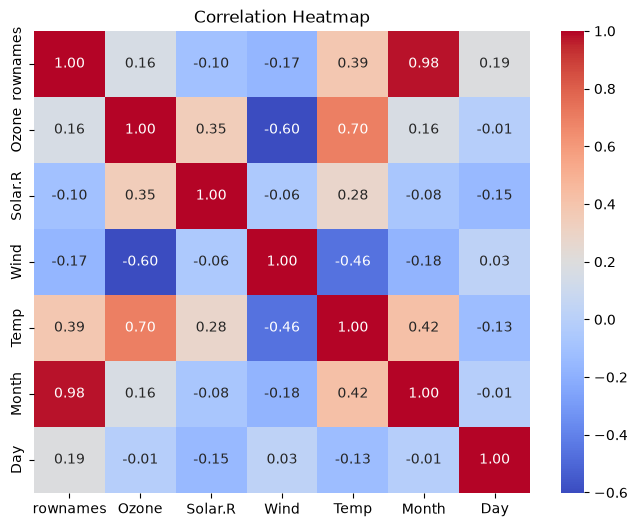

In [31]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [32]:
def correlation_strength(value):
    value = abs(value)
    if value <= 0.1:
        return "No correlation"
    elif value <= 0.3:
        return "Weak"
    elif value <= 0.5:
        return "Moderate"
    elif value <= 0.7:
        return "Strong"
    else:
        return "Very strong"
for a, b in pairs:
    correlation = df[a].corr(df[b])
    print(f"{a} vs {b}: {correlation:.3f} - {correlation_strength(correlation)}")

Ozone vs Solar.R: 0.348 - Moderate
Ozone vs Wind: -0.602 - Strong
Ozone vs Temp: 0.698 - Strong
Solar.R vs Wind: -0.057 - No correlation
Solar.R vs Temp: 0.276 - Weak
Wind vs Temp: -0.458 - Moderate


In [33]:
mean_ozone = df.groupby('Month')['Ozone'].mean()
print("Mean Ozone by Month:")
print(mean_ozone)

Mean Ozone by Month:
Month
5    23.615385
6    29.444444
7    59.115385
8    59.961538
9    31.448276
Name: Ozone, dtype: float64


In [34]:
median_wind = df.groupby('Month')['Wind'].median()
print("Median Wind by Month:")
print(median_wind)

Median Wind by Month:
Month
5    11.5
6     9.7
7     8.6
8     8.6
9    10.3
Name: Wind, dtype: float64


In [35]:
max_temp = df.groupby('Month')['Temp'].max()
print("Maximum Temperature by Month:")
print(max_temp)

Maximum Temperature by Month:
Month
5    81
6    93
7    92
8    97
9    93
Name: Temp, dtype: int64


In [36]:
solar_sd = df.groupby('Month')['Solar.R'].std()
print("Solar.R Standard Deviation by Month:")
print(solar_sd)

Solar.R Standard Deviation by Month:
Month
5    115.075499
6     92.882975
7     80.568344
8     76.834943
9     79.118280
Name: Solar.R, dtype: float64


In [ ]:
df['Ozone_Missing'] = df['Ozone'].isnull()
temp_comparison = df.groupby('Ozone_Missing')['Temp'].mean()
print("Average Temperature:")
print(temp_comparison)

Average Temperature:
Ozone_Missing
False    77.870690
True     77.918919
Name: Temp, dtype: float64


In [ ]:
df['Ozone_Missing'] = df['Ozone'].isnull()
temp_comparison = df.groupby('Ozone_Missing')['Temp'].mean()
print("Average Temperature:")
print(temp_comparison)

Average Temperature:
Ozone_Missing
False    77.870690
True     77.918919
Name: Temp, dtype: float64


In [40]:
missing_ozone = df.groupby('Month')['Ozone'].apply(
    lambda x: x.isnull().mean() * 100)
print("Percentage of Missing Ozone by Month:")
print(missing_ozone)

Percentage of Missing Ozone by Month:
Month
5    16.129032
6    70.000000
7    16.129032
8    16.129032
9     3.333333
Name: Ozone, dtype: float64


In [41]:
def detect_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers

In [42]:
for col in cols:
    outliers = detect_outliers(df[col].dropna())
    
    print(col)
    print("Number of outliers:", len(outliers))
    print("Outliers:", outliers.tolist())
    print()

Ozone
Number of outliers: 2
Outliers: [135.0, 168.0]

Solar.R
Number of outliers: 0
Outliers: []

Wind
Number of outliers: 3
Outliers: [20.1, 18.4, 20.7]

Temp
Number of outliers: 0
Outliers: []



In [43]:
print("Skewness:")
print(df[cols].skew())

print("\nKurtosis:")
print(df[cols].kurt())

Skewness:
Ozone      1.241796
Solar.R   -0.428045
Wind       0.347818
Temp      -0.377884
dtype: float64

Kurtosis:
Ozone      1.290303
Solar.R   -0.968467
Wind       0.111418
Temp      -0.403505
dtype: float64


In [44]:
for col in cols:
    skew = df[col].skew()

    if abs(skew) < 0.5:
        result = "Approximately symmetric"
    elif skew > 0:
        result = "Positively skewed"
    else:
        result = "Negatively skewed"

    print(f"{col}: {skew:.3f} - {result}")

Ozone: 1.242 - Positively skewed
Solar.R: -0.428 - Approximately symmetric
Wind: 0.348 - Approximately symmetric
Temp: -0.378 - Approximately symmetric


In [45]:
top_ozone = df.nlargest(3, 'Ozone')

print("Top 3 Highest Ozone Readings:")
print(top_ozone[['Ozone', 'Solar.R', 'Wind', 'Temp']])

Top 3 Highest Ozone Readings:
     Ozone  Solar.R  Wind  Temp
116  168.0    238.0   3.4    81
61   135.0    269.0   4.1    84
98   122.0    255.0   4.0    89


In [46]:
lowest_wind = df.nsmallest(3, 'Wind')
print("Top 3 Lowest Wind Readings:")
print(lowest_wind[['Wind', 'Ozone', 'Solar.R', 'Temp']])

Top 3 Lowest Wind Readings:
     Wind  Ozone  Solar.R  Temp
52    1.7    NaN     59.0    76
120   2.3  118.0    225.0    94
125   2.8   73.0    183.0    93


In [47]:
temp_comparison = df.groupby(
    df['Ozone'] > 60
)['Temp'].mean()

print("Average Temperature:")
print(temp_comparison)

Average Temperature:
Ozone
False    75.262295
True     88.193548
Name: Temp, dtype: float64


In [ ]:
mean_wind = df['Wind'].mean()

solar_comparison = df.groupby(
    df['Wind'] > mean_wind
)['Solar.R'].mean()
print("Mean Wind:", mean_wind)
print("\nAverage Solar.R:")
print(solar_comparison)

Mean Wind: 9.957516339869281

Average Solar.R:
Wind
False    187.881579
True     183.814286
Name: Solar.R, dtype: float64


In [ ]:
df['Temp_Range'] = pd.cut(
    df['Temp'],
    bins=[-np.inf, 60, 80, np.inf],
    labels=['Below 60°F', '60–80°F', 'Above 80°F']
)
max_ozone_temp = df.groupby(
    'Temp_Range',
    observed=True
)['Ozone'].max()
print("Maximum Ozone by Temperature Range:")
print(max_ozone_temp)

Maximum Ozone by Temperature Range:
Temp_Range
Below 60°F     19.0
60–80°F       115.0
Above 80°F    168.0
Name: Ozone, dtype: float64


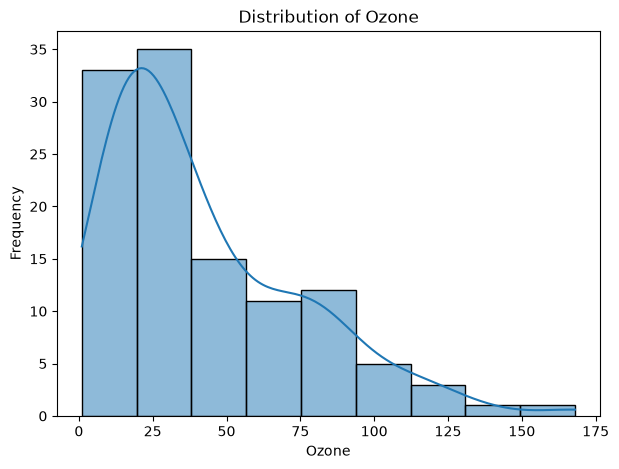

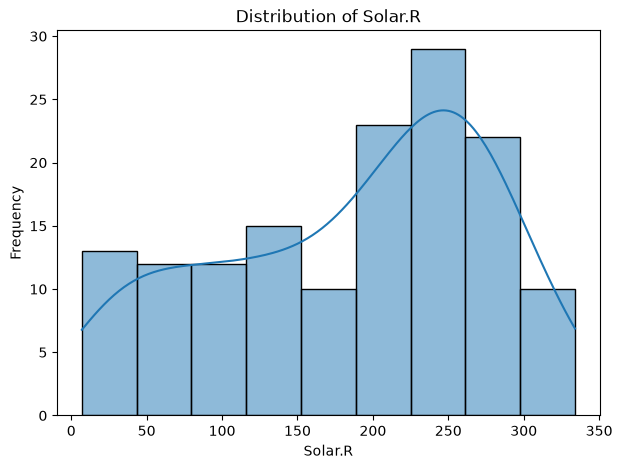

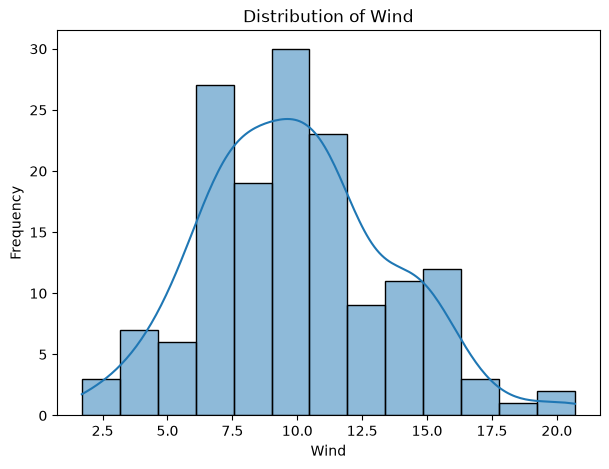

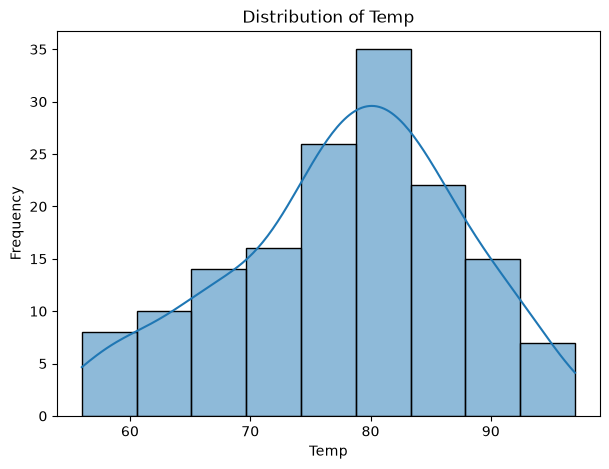

In [ ]:
for col in cols:
    plt.figure(figsize=(7, 5))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

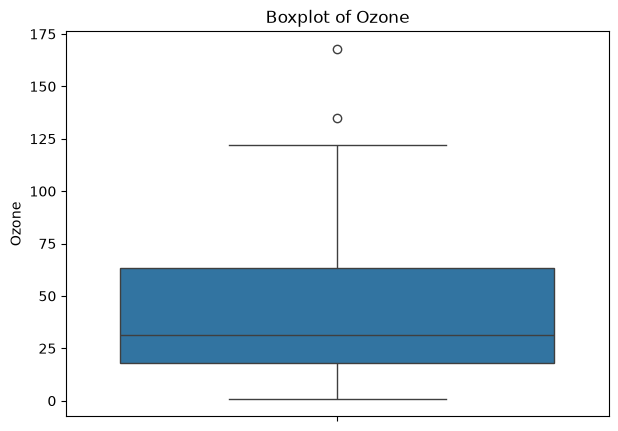

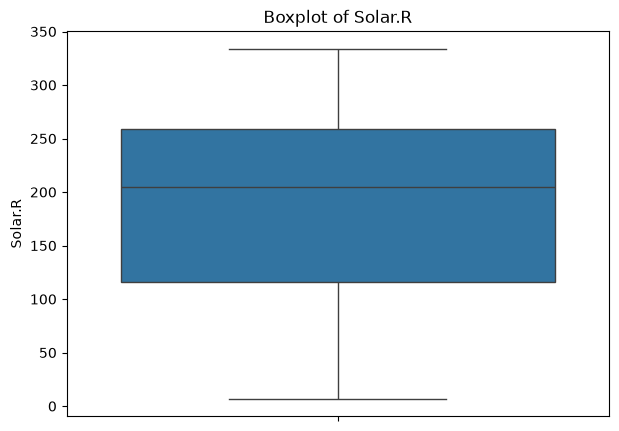

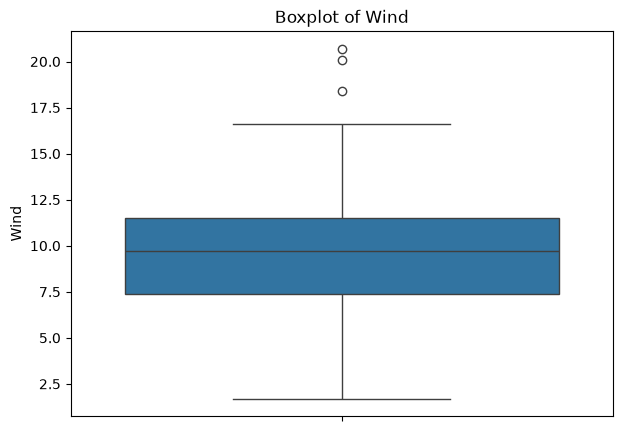

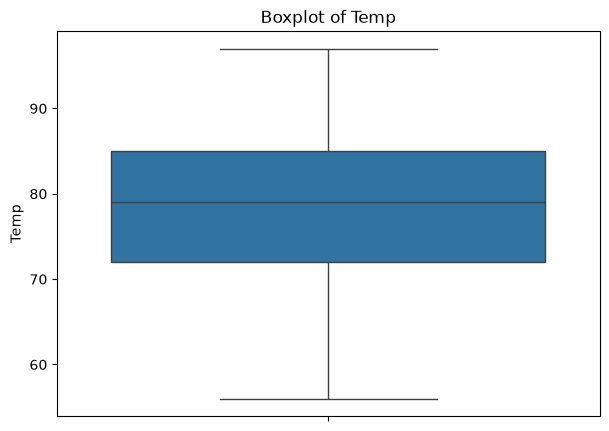

In [51]:
for col in cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

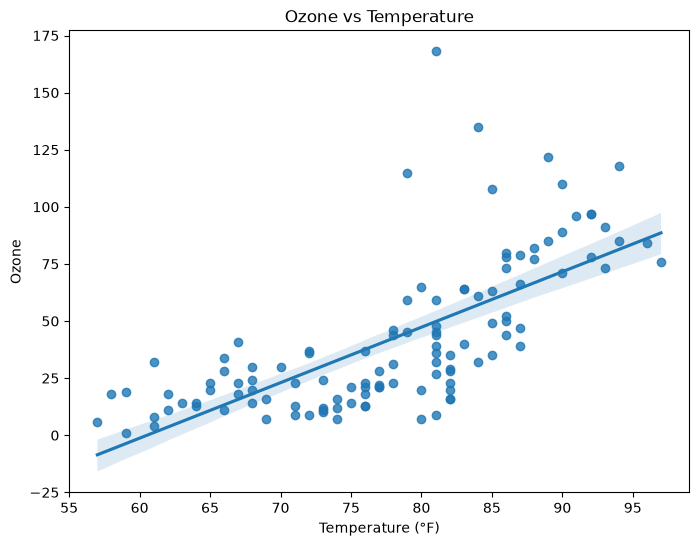

In [52]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Temp', y='Ozone')
plt.title("Ozone vs Temperature")
plt.xlabel("Temperature (°F)")
plt.ylabel("Ozone")
plt.show()

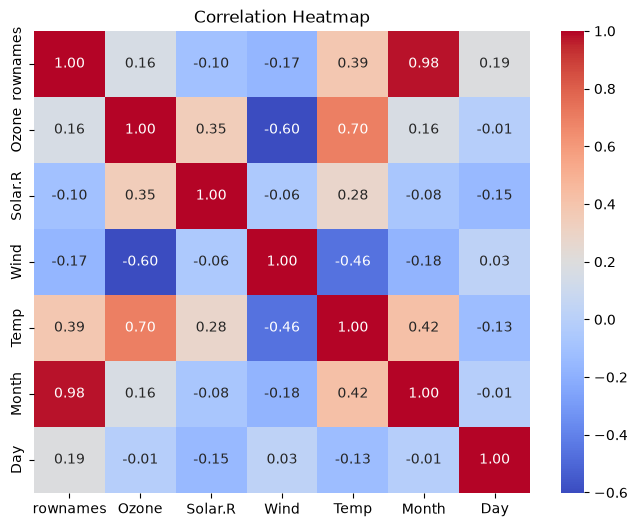

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

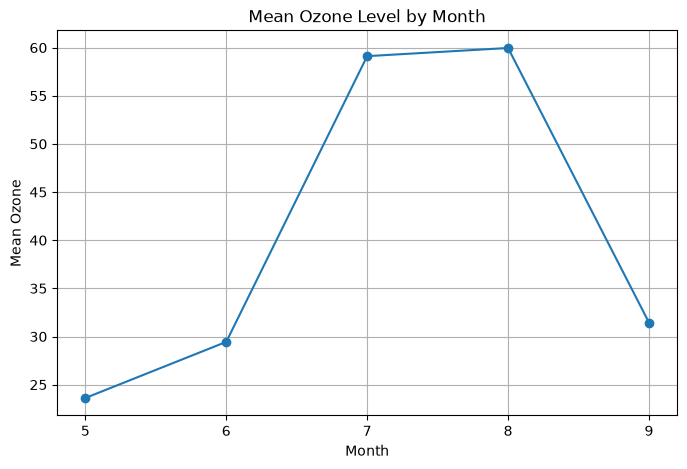

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(
    mean_ozone.index,
    mean_ozone.values,
    marker='o'
)
plt.title("Mean Ozone Level by Month")
plt.xlabel("Month")
plt.ylabel("Mean Ozone")
plt.xticks(mean_ozone.index)
plt.grid(True)
plt.show()